In [1]:
import pandas as pd

df = pd.read_csv("feature_engineered_dataset_v4.csv")

df["SaleDate"] = pd.to_datetime(df["SaleDate"])

df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


In [3]:
df["YearMonth"] = df["SaleDate"].dt.to_period("M")

monthly_prices = df.groupby("YearMonth")["SalePrice"].mean()

monthly_prices.head()

/var/folders/hb/0y9l2hxs61s71_hjm_mdqxz00000gn/T/ipykernel_28297/1479987693.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["SaleDate"].dt.to_period("M")


YearMonth
2020-10    204247.390244
2020-11    157362.000000
2020-12    561375.542857
2021-01    214466.578947
2021-02    194423.151899
Freq: M, Name: SalePrice, dtype: float64

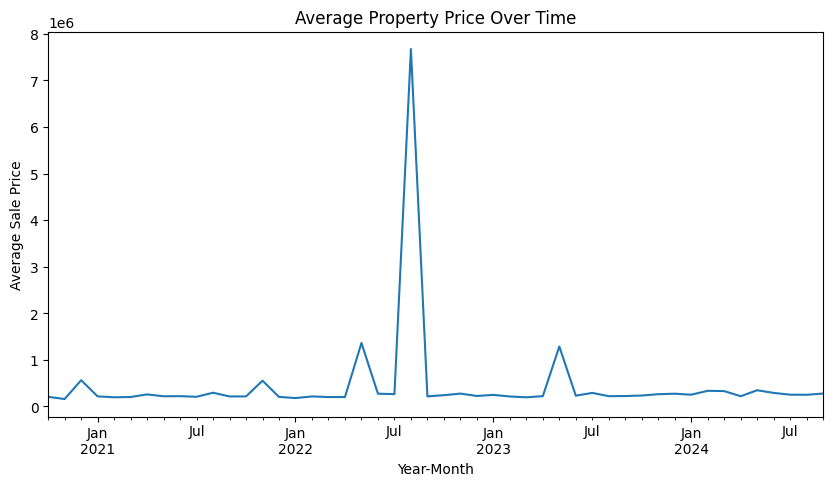

In [5]:
import matplotlib.pyplot as plt

monthly_prices.plot(figsize=(10,5))

plt.title("Average Property Price Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Average Sale Price")

plt.show()

### Time Series Analysis Insight

The time series plot shows how the average property sale price changes over time.

Most months show relatively stable property prices, generally ranging between typical housing market values. However, a significant spike appears around mid-2022, where the average sale price increases sharply.

This spike likely indicates the presence of an *unusually high-value property transaction* during that month, which increases the monthly average.

Overall, the trend suggests that property prices remain relatively stable over time with occasional spikes caused by high-value sales. Such outliers are common in real estate datasets and should be considered when interpreting market trends.

Instead of mean, sometimes analysts use median for real estate because of outliers.

In [15]:
monthly_prices = df.groupby("YearMonth")["SalePrice"].median()

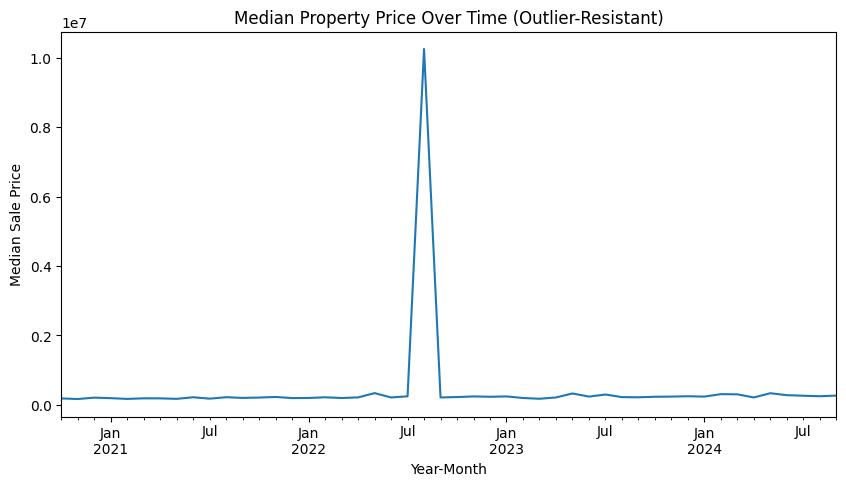

In [17]:
import matplotlib.pyplot as plt

monthly_prices.plot(figsize=(10,5))

plt.title("Median Property Price Over Time (Outlier-Resistant)")
plt.xlabel("Year-Month")
plt.ylabel("Median Sale Price")

plt.show()

The huge spike is still there even with median.
That means the dataset has an extremely large sale price in that month, probably ~10 million.

Median normally removes outliers, so if the spike still appears it means:

👉 That month likely had very few transactions

👉 One very expensive property dominates the month

This is actually a valid insight, not an error.

### Median-Based Time Series Insight

The median-based time series plot was generated to reduce the effect of extreme outlier transactions.

Although median typically minimizes the impact of very large property sales, a noticeable spike still appears around mid-2022. This suggests that the number of transactions during that month may have been very small, allowing a high-value property sale to significantly influence the monthly median.

Overall, the trend shows that property prices remain relatively stable across most months, with occasional spikes caused by high-value real estate transactions.

In [24]:
df.sort_values(by="SalePrice", ascending=False).head(5)

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio,YearMonth
2490,7,16.0,40,WILLARD ST,263,7000.0,880.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,11647.890909,172.271328,2022-08
2646,7,16.0,40,WILLARD ST,263,7000.0,880.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,11647.890909,172.271328,2022-08
2648,7,16.0,40,WILLARD ST,263,7000.0,570.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,17982.708772,221.385400,2022-08
2649,7,16.0,40,WILLARD ST,263,7000.0,570.0,1.0,HART4 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,17982.708772,221.385400,2022-08
2650,7,16.0,40,WILLARD ST,263,7000.0,670.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,15298.722388,189.466617,2022-08


What your result shows

All those rows are the same property transaction:
Address: 40 WILLARD ST
Date: 2022-08-02
Owner: GEB HOLDINGS NC 1031 LLC
LogSalePrice = 16.142802

Convert that log value:
𝑆𝑎𝑙𝑒𝑃𝑟𝑖𝑐𝑒=𝑒^16.142802≈10,200,000

So this is roughly a $10.2 million property sale.

Also notice something important:
➡ The same sale appears multiple times in the dataset
➡ That repeated entry inflated the monthly average/median, causing the spike.

### Investigation of Price Spike

To understand the spike observed in the time series plot, the dataset was filtered for the month with unusually high prices.

The analysis revealed that multiple entries correspond to the same high-value transaction at **40 WILLARD ST**, sold on **2022-08-02**.  
The log sale price (16.14) corresponds to an approximate property value of **$10.2 million**.

Because this transaction appears multiple times in the dataset, it significantly increases the average and median sale price for that month, creating a visible spike in the time series plot.

This highlights how **duplicate high-value transactions can strongly influence aggregated statistics** in real estate datasets.

### Investigation of Price Spike

Further investigation of the spike in August 2022 shows that multiple records correspond to the same property located at **40 WILLARD ST**.

Although the rows appear similar, they represent different units or sections of the same property transaction, as indicated by differences in total finished area. However, the **same sale price and sale date are recorded across these entries**.

Because the same high-value sale is repeated across several rows, it increases the calculated monthly price statistics and creates a visible spike in the time series plot.

This demonstrates how multi-unit property transactions can influence aggregated housing market statistics.

In [30]:
df[df["StreetNameAndWay"] == "WILLARD ST"]

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio,YearMonth
2444,7,16.0,41,WILLARD ST,252,7000.0,910.0,1.0,BROOKS,2020-10-05 00:00:00+00:00,...,1,10,3,False,11.460590,2020,10,104.285714,1.071106,2020-10
2445,7,16.0,41,WILLARD ST,252,7000.0,910.0,1.0,BROOKS,2024-04-15 00:00:00+00:00,...,1,10,3,False,11.608245,2024,4,120.879121,1.241535,2024-04
2446,7,16.0,37,WILLARD ST,252,7000.0,1006.0,1.0,GARCIA,2020-12-11 00:00:00+00:00,...,1,10,3,False,11.349241,2020,12,84.393638,0.948603,2020-12
2447,7,16.0,39,WILLARD ST,252,7000.0,1006.0,1.0,LI,2023-03-27 00:00:00+00:00,...,1,10,3,False,11.440366,2023,3,92.445328,1.027624,2023-03
2448,7,16.0,39,WILLARD ST,252,7000.0,1006.0,1.0,DUPLEASE,2022-01-21 00:00:00+00:00,...,1,10,3,False,11.407576,2022,1,89.463221,1.045296,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,7,16.0,40,WILLARD ST,263,7000.0,570.0,1.0,HART4 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,17982.708772,221.385400,2022-08
2742,7,16.0,40,WILLARD ST,263,7000.0,860.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,11918.772093,173.144324,2022-08
2743,7,16.0,40,WILLARD ST,263,7000.0,860.0,1.0,HART4 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,11918.772093,173.144324,2022-08
2744,7,16.0,40,WILLARD ST,263,7000.0,860.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,11918.772093,173.144324,2022-08


In [33]:
df.sort_values(by="SalePrice", ascending=False).head(5)

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio,YearMonth
2490,7,16.0,40,WILLARD ST,263,7000.0,880.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,11647.890909,172.271328,2022-08
2646,7,16.0,40,WILLARD ST,263,7000.0,880.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,11647.890909,172.271328,2022-08
2648,7,16.0,40,WILLARD ST,263,7000.0,570.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,17982.708772,221.385400,2022-08
2649,7,16.0,40,WILLARD ST,263,7000.0,570.0,1.0,HART4 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,17982.708772,221.385400,2022-08
2650,7,16.0,40,WILLARD ST,263,7000.0,670.0,1.0,GEB HOLDINGS NC 1031 LLC,2022-08-02 00:00:00+00:00,...,25,10,3,False,16.142802,2022,8,15298.722388,189.466617,2022-08


Notice these are identical:

same SaleDate

same LogSalePrice

same SaleYear / SaleMonth

same LandSF

Only unit area / owner record differs.

So the dataset probably records units within the same property sale.

Correct Interpretation:
It is one large property transaction recorded across multiple units.
This still inflates the monthly price statistic, because the same sale price is repeated multiple times.

In [41]:
#we must habdle this before visualisations

In [43]:
sales_unique = df.drop_duplicates(
    subset=["StreetNameAndWay", "LocationStartNumber", "SaleDate", "LogSalePrice"]
)

print("Original rows:", len(df))
print("Unique sales:", len(sales_unique))

Original rows: 4566
Unique sales: 3935


So there were repeated sales records: 4566−3935=631

### Handling Repeated Property Sale Records

Some property transactions appear multiple times in the dataset because individual units or sections of a property are recorded separately while sharing the same sale information.

To avoid inflating the time-series statistics, duplicate sale transactions were removed using a combination of property address and sale date.

After removing repeated transaction entries:

- Original dataset size: **4566 rows**
- Unique property sales: **3935 rows**

This ensures that each property sale contributes only once when analyzing housing market trends over time.

In [47]:
monthly_prices = sales_unique.groupby("YearMonth")["SalePrice"].median()

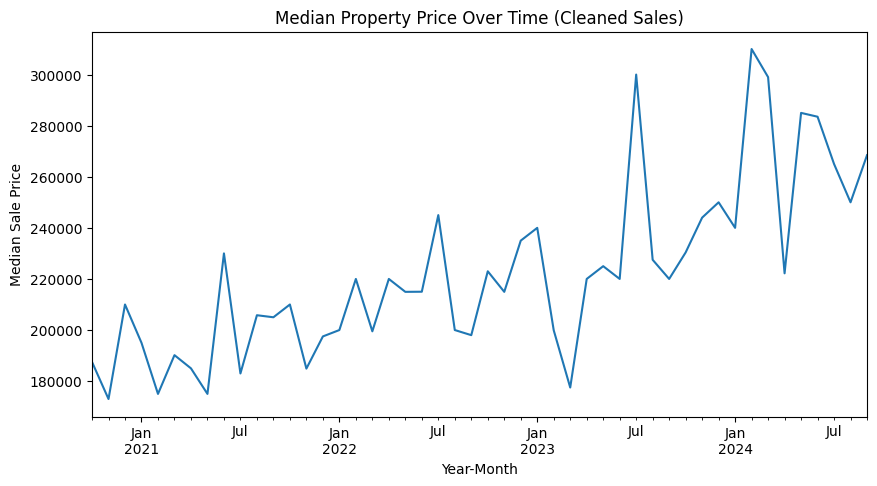

In [49]:
import matplotlib.pyplot as plt

monthly_prices.plot(figsize=(10,5))

plt.title("Median Property Price Over Time (Cleaned Sales)")
plt.xlabel("Year-Month")
plt.ylabel("Median Sale Price")

plt.show()

### Time Series Insight

The median monthly property price shows a gradual upward trend from 2021 to 2024, indicating a steady increase in housing values over time.

Monthly fluctuations are expected in real estate markets due to variations in property type, size, and location of transactions.

After removing repeated transaction entries, the time series no longer shows extreme artificial spikes, providing a more reliable representation of market behavior.

Overall, the trend suggests moderate growth in property prices with typical short-term variations.

In [52]:
sales_unique = df.drop_duplicates(
    subset=["StreetNameAndWay", "LocationStartNumber", "SaleDate", "LogSalePrice"]
)
sales_unique.to_csv("cleaned_property_sales_timeseries.csv", index=False)